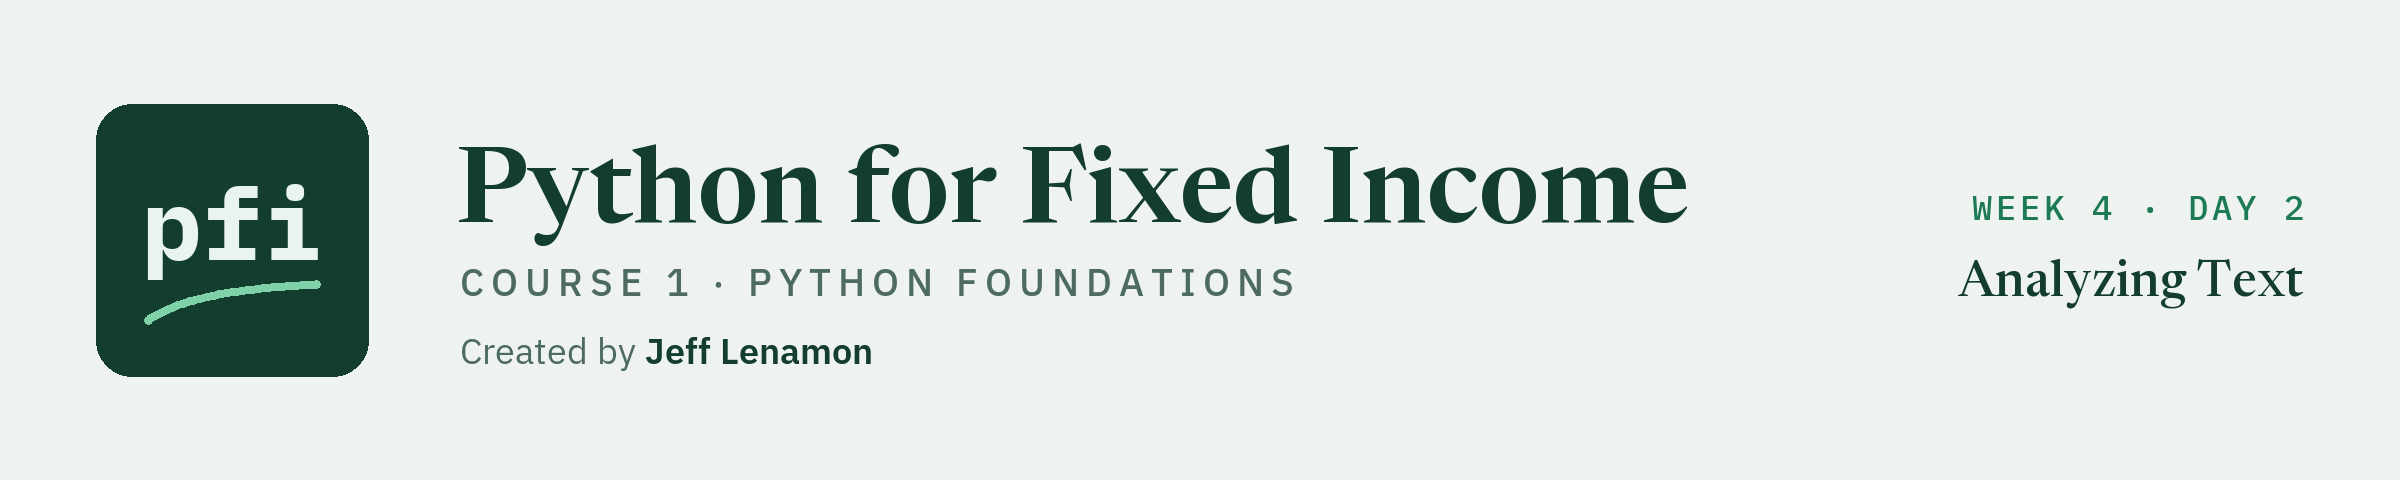

# Analyzing Text

Week 4. Text is data too. Take one published statement as a Python string, pull figures out of it, clean it, and count its words. Then do the same to a table of 46 statements.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week4/day2/17_analyzing_text.ipynb)

After each of its meetings, the Federal Open Market Committee publishes a short statement. The credit desk keeps every one of them, and until now nobody has done anything with the file except read it.

The portfolio manager asks for a table, not an opinion: for each statement, how long it is, which figures it contains, how often a short list of words appears, and how much of its wording is shared with the statement before it. You are the desk's analyst, and the job is to turn text into numbers that can be checked.

**What this notebook does and does not do.** It counts. It reports that a word appears a number of times in the statement of a given date, or that a word count went from one number to another. It does not say what a statement means, what the Committee did or will do, or why any wording changed. It scores no tone and makes no forecast. Reading policy is a different job, and it is not taught here.

The order of work:

1. **Strings again.** The string tools from notebook 01, on one paragraph.
2. **Regular expressions.** A small language for describing patterns in text, used to pull out figures and names, to take a bond description apart, and to test the shape of an identifier.
3. **Cleaning.** Lower case, punctuation, white space, and splitting into words, one step at a time.
4. **Stopwords.** Removing the words that every English text is full of.
5. **Stemming.** Cutting words down to a common root.
6. **Text into numbers.** Counts for every statement, held in a table and drawn as charts.

**The data.** The text is real and public, and it is the only real data in this notebook. The one use of portfolio data is at the end of section 17.3, which uses bond descriptions typed from the course's synthetic holdings file and reads its identifiers.

* Source: Board of Governors of the Federal Reserve System, Federal Open Market Committee statements, federalreserve.gov. Each statement was downloaded from its own press release page, which is linked from the calendar page https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm. Retrieved on 2026-10-03.
* Span: the 46 statements from 2021-01-27 to 2026-09-16, which is every scheduled meeting of 2021 to 2025 and of 2026 up to the retrieval date.
* Reuse: the Board's website says, at https://www.federalreserve.gov/disclaimer.htm, "Unless otherwise indicated, information on Board's website is in the public domain and may be copied and distributed without permission. Please cite to the Board as the source of the information."
* The text in the file is exactly as published. The only change made when the file was built was to white space: one space between words, and one line break between paragraphs.
* When this notebook quotes a statement, it prints the words from the file and gives the statement's date.

## 17.1 Setting Up

Q. Import the libraries and check which versions are running.

In [1]:
# os is used to find the data folder, and re is Python's module for regular expressions
import os
import re

# Counter counts how often each value appears in a list
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns

print('pandas version:', pd.__version__)
print('matplotlib version:', matplotlib.__version__)
print('seaborn version:', sns.__version__)
print('nltk version:', nltk.__version__)

pandas version: 3.0.6
matplotlib version: 3.11.2
seaborn version: 0.13.2
nltk version: 3.10.3


* Three names are new. `re` and `collections` come with Python, so there is nothing to install. `nltk`, the Natural Language Toolkit, is a library for working with text, and it is in the course's `requirements.txt`.
* This notebook was saved with the versions printed above. Yours may differ, and in Google Colab they may be older.

Q. Load the statements.

In [2]:
# on your own machine the file is in the repo's data folder. In Colab it is read from GitHub.
if os.path.exists('../../../data/fomc_statements.csv'):
    data_file = '../../../data/fomc_statements.csv'
else:
    data_file = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/fomc_statements.csv'

statements = pd.read_csv(data_file)

print('Rows and columns:', statements.shape)
print('First date:', statements['date'].min(), ' last date:', statements['date'].max())

statements.head(3)

Rows and columns: (46, 3)
First date: 2021-01-27  last date: 2026-09-16


,date,url,text
0,2021-01-27,https://www.federalreserve.gov/newsevents/pres...,The Federal Reserve is committed to using its ...
1,2021-03-17,https://www.federalreserve.gov/newsevents/pres...,The Federal Reserve is committed to using its ...
2,2021-04-28,https://www.federalreserve.gov/newsevents/pres...,The Federal Reserve is committed to using its ...


* 46 rows and 3 columns: the `date` of the statement, the `url` of its page, and the `text`.
* The first statement is dated 2021-01-27 and the last 2026-09-16.
* pandas shows only the start of each text, because a whole statement does not fit in a table cell.

Q. Take one statement out of the table, to work on as a plain Python string.

In [3]:
# the row dated 2023-11-01, the text column, and the one value in it
statement = statements.loc[statements['date'] == '2023-11-01', 'text'].iloc[0]

print('Type:', type(statement))

# the paragraphs of a statement are separated by a line break, which Python writes as \n
paragraphs = statement.split('\n')
print('Paragraphs:', len(paragraphs))

# the first paragraph is the running example of the next section
opening = paragraphs[0]
print('Statement dated 2023-11-01, first paragraph:')
print(opening)

Type: <class 'str'>
Paragraphs: 5
Statement dated 2023-11-01, first paragraph:
Recent indicators suggest that economic activity expanded at a strong pace in the third quarter. Job gains have moderated since earlier in the year but remain strong, and the unemployment rate has remained low. Inflation remains elevated.


* `statement` is a `str`, the same type as a ticker or an issuer name in notebook 01. It is only longer.
* `'\n'` is the line break character. Splitting on it gives a list of 5 paragraphs.
* `opening` is the first paragraph, three sentences long. Every example in the next section uses it, so the numbers can be checked by eye.

## 17.2 Strings Again

Notebook 01 introduced strings. A handful of string tools do a large share of all text work, and each has a twin in Excel. For the Excel formulas in this section, suppose the paragraph is in cell A2.

Q. How long is the paragraph, in characters?

In [4]:
# len() counts every character: letters, spaces, and punctuation
print('Characters in the paragraph:', len(opening))
print('Characters in the whole statement:', len(statement))

Characters in the paragraph: 238
Characters in the whole statement: 2300


* 238 characters in the paragraph and 2,300 in the statement.
* In Excel: `=LEN(A2)` returns 238.

Q. Write the paragraph in lower case, and in capitals.

In [5]:
# lower() and upper() return a new string. opening itself is not changed.
print(opening.lower())
print(opening.upper())

recent indicators suggest that economic activity expanded at a strong pace in the third quarter. job gains have moderated since earlier in the year but remain strong, and the unemployment rate has remained low. inflation remains elevated.
RECENT INDICATORS SUGGEST THAT ECONOMIC ACTIVITY EXPANDED AT A STRONG PACE IN THE THIRD QUARTER. JOB GAINS HAVE MODERATED SINCE EARLIER IN THE YEAR BUT REMAIN STRONG, AND THE UNEMPLOYMENT RATE HAS REMAINED LOW. INFLATION REMAINS ELEVATED.


* In Excel: `=LOWER(A2)` and `=UPPER(A2)`.
* A string method never changes the string it is called on. It hands back a new one. To keep the result, store it in a variable.

**Predict 1**

The last sentence of the paragraph is `Inflation remains elevated.`

```
'inflation' in opening
```

What does it return?

> A) `True`, because the word is in the paragraph.
>
> B) `False`.

Decide, then run the cell.

In [6]:
# in asks whether one string appears inside another
print("'inflation' in opening:", 'inflation' in opening)
print("'Inflation' in opening:", 'Inflation' in opening)

# the usual fix: put the text in lower case first, then look for the lower-case word
print("'inflation' in opening.lower():", 'inflation' in opening.lower())

'inflation' in opening: False
'Inflation' in opening: True
'inflation' in opening.lower(): True


* The answer is B. Python compares characters, and `i` is not `I`. The paragraph holds `Inflation` with a capital, so the lower-case word is not found.
* Putting the text in lower case before searching is the first cleaning step of section 17.4, and this is the reason for it.

**Excel side by side.** Excel has both behaviours, in two functions.

| Job | Python | Excel | Result |
| --- | --- | --- | --- |
| Is it there, capitals matter | `'inflation' in opening` | `=ISNUMBER(FIND("inflation", A2))` | False |
| Is it there, capitals ignored | `'inflation' in opening.lower()` | `=ISNUMBER(SEARCH("inflation", A2))` | True |

`FIND` tells capitals from lower case and `SEARCH` does not. Both return the position of the text, or the error `#VALUE!` when it is not there, which is why `ISNUMBER` is wrapped around them.

Q. Where in the paragraph does `Inflation` start?

In [7]:
# find() returns the position of the first match. Python counts positions from 0.
position = opening.find('Inflation')
print('Position:', position)

# a slice takes the characters from one position up to, and not including, another
print('First 6 characters:', opening[:6])
print('9 characters from the position:', opening[position:position + 9])
print('Last 9 characters:', opening[-9:])

Position: 211
First 6 characters: Recent
9 characters from the position: Inflation
Last 9 characters: elevated.


* `find()` returns 211. Python counts from 0, so that is the 212th character.
* Slices do the work of three Excel functions.

| Job | Python | Excel | Result |
| --- | --- | --- | --- |
| Position of a word | `opening.find('Inflation')` | `=FIND("Inflation", A2)` | 211 in Python, 212 in Excel |
| Characters from the left | `opening[:6]` | `=LEFT(A2, 6)` | Recent |
| Characters from the middle | `opening[211:220]` | `=MID(A2, 212, 9)` | Inflation |
| Characters from the right | `opening[-9:]` | `=RIGHT(A2, 9)` | elevated. |

Excel counts positions from 1 and Python from 0. That one difference explains the 211 and the 212.

Q. How many times does `rate` appear in the paragraph?

In [8]:
# count() counts how many times a piece of text appears
print("count('rate'):", opening.count('rate'))
print("count('remain'):", opening.count('remain'))

count('rate'): 2
count('remain'): 3


* `count('rate')` returns 2. Read the paragraph: the word rate is there once, in `the unemployment rate`. The second match is inside `moderated`.
* `count('remain')` returns 3: `remain`, `remained`, and `remains`.
* `count()` counts pieces of text, not words. It does not know where a word starts or ends. Section 17.3 fixes this.

**Excel side by side.** Excel has no function that counts a word inside a cell, and the standard formula for it is built from two others. Remove the word, and see how much shorter the text became:

`=(LEN(A2) - LEN(SUBSTITUTE(A2, "rate", ""))) / LEN("rate")`

It returns 2, the same answer as `count('rate')`, for the same reason: `SUBSTITUTE` also replaces `rate` inside `moderated`. `SUBSTITUTE` tells capitals from lower case, as `count()` does.

Q. Split the paragraph into words. How many are there?

In [9]:
# split() with nothing in the brackets cuts the text at every run of white space
words = opening.split()

print('Words:', len(words))
print('First five:', words[:5])
print('Last three:', words[-3:])

Words: 37
First five: ['Recent', 'indicators', 'suggest', 'that', 'economic']
Last three: ['Inflation', 'remains', 'elevated.']


* 37 words. `split()` returns a list, so everything notebook 01 said about lists applies: `len()`, positions, slices.
* The last item is `'elevated.'` with its full stop attached. `split()` cuts at spaces and nothing else. Punctuation stays stuck to the word next to it.

Q. Join the first five words back into one string.

In [10]:
# join() is the reverse of split(). The string in front is what goes between the items.
print(' '.join(words[:5]))
print('-'.join(words[:5]))

Recent indicators suggest that economic
Recent-indicators-suggest-that-economic


* `' '.join(...)` puts a space between the items, and `'-'.join(...)` puts a hyphen.

**Excel side by side.**

| Job | Python | Excel | Result |
| --- | --- | --- | --- |
| Split into words | `opening.split()` | `=TEXTSPLIT(A2, " ")` | 37 cells across a row |
| Number of words | `len(opening.split())` | `=COUNTA(TEXTSPLIT(A2, " "))` | 37 |
| Number of words, any version | | `=LEN(TRIM(A2)) - LEN(SUBSTITUTE(TRIM(A2), " ", "")) + 1` | 37 |
| Join with a separator | `' '.join(words[:5])` | `=TEXTJOIN(" ", TRUE, B2:F2)` | Recent indicators suggest that economic |

`TEXTSPLIT` is in Microsoft 365 and Excel 2024. The third row works in every version: it counts the spaces and adds one. On the Data tab, Text to Columns does the same split by hand, with Delimited and Space chosen.

Q. Split the paragraph into sentences at each full stop.

In [11]:
# split('.') cuts at every full stop, and the full stops themselves are dropped
pieces = opening.split('.')

# repr() prints a string with its quotes, so that spaces at the ends can be seen
for piece in pieces:
    print(repr(piece))

'Recent indicators suggest that economic activity expanded at a strong pace in the third quarter'
' Job gains have moderated since earlier in the year but remain strong, and the unemployment rate has remained low'
' Inflation remains elevated'
''


* Four pieces. The second and third start with a space, the one that followed the full stop. The fourth is empty: it is what comes after the last full stop, which is nothing.

Q. Remove the spaces at the ends of each piece, and drop the empty one.

In [12]:
# strip() removes white space from both ends of a string
# the if at the end keeps a piece only when something is left after stripping
sentences = [piece.strip() for piece in pieces if piece.strip() != '']

for sentence in sentences:
    print(repr(sentence))
print('Sentences:', len(sentences))

'Recent indicators suggest that economic activity expanded at a strong pace in the third quarter'
'Job gains have moderated since earlier in the year but remain strong, and the unemployment rate has remained low'
'Inflation remains elevated'
Sentences: 3


* 3 sentences, with no stray spaces.
* In Excel: `=TRIM(B2)`. `TRIM` goes one step further than `strip()`: it also reduces any run of spaces inside the text to a single space. `TRIM` removes only the ordinary space. `strip()` also removes tabs, line breaks, and non-breaking spaces at the ends.
* Splitting on a full stop is rough. It would also cut `U.S.` into pieces. It works on this paragraph because the only full stops in it end sentences.

Q. Replace one piece of text with another.

In [13]:
# replace() swaps every appearance of the first string for the second
print(sentences[2])
print(sentences[2].replace('Inflation', 'INFLATION'))

# replacing with an empty string removes the text
print(opening.replace('.', ''))

Inflation remains elevated
INFLATION remains elevated
Recent indicators suggest that economic activity expanded at a strong pace in the third quarter Job gains have moderated since earlier in the year but remain strong, and the unemployment rate has remained low Inflation remains elevated


* `replace()` changed one word in the first call and removed all 3 full stops in the second.
* In Excel: `=SUBSTITUTE(A2, ".", "")` for the formula, or Home, Find and Select, Replace (Ctrl+H) to change the cells in place. The formula leaves the original in A2. Replace overwrites it.

| Tool | What it does | Excel |
| --- | --- | --- |
| `len(text)` | number of characters | `LEN` |
| `text.lower()`, `text.upper()` | change the case | `LOWER`, `UPPER` |
| `'word' in text` | is it there | `ISNUMBER(FIND(...))`, `ISNUMBER(SEARCH(...))` |
| `text.find('word')` | where it starts | `FIND`, `SEARCH` |
| `text[a:b]` | a slice | `LEFT`, `MID`, `RIGHT` |
| `text.count('word')` | how many times | `LEN` less `LEN(SUBSTITUTE(...))` |
| `text.split()` | cut into a list | `TEXTSPLIT`, Text to Columns |
| `' '.join(items)` | glue a list together | `TEXTJOIN` |
| `text.strip()` | remove spaces at the ends | `TRIM` |
| `text.replace(old, new)` | swap text | `SUBSTITUTE`, Find and Replace |

These tools all look for one exact piece of text. The next section looks for a pattern.

## 17.3 Regular Expressions

A statement gives its figures in its own style: `2 percent`, `5-1/4 to 5-1/2 percent`. No single piece of text finds them all, because the digits differ each time. What they share is a shape: some digits, then the word percent.

A **regular expression**, or regex, is a way to write down a shape. Python's `re` module searches text for it. Three functions cover most needs:

* `re.findall(pattern, text)` returns a list of every match;
* `re.search(pattern, text)` returns the first match, with its position;
* `re.sub(pattern, new, text)` replaces every match.

The examples use the third paragraph of the same statement.

Q. Print the first two sentences of the third paragraph.

In [14]:
# the third paragraph is at position 2 of the list
policy = paragraphs[2]

# this paragraph has no abbreviations, so a full stop and a space mark the end of a sentence
policy_sentences = policy.split('. ')

print('Statement dated 2023-11-01, third paragraph, first two sentences:')
print(policy_sentences[0] + '.')
print(policy_sentences[1] + '.')
print('Characters in the paragraph:', len(policy), ' sentences:', len(policy_sentences))

Statement dated 2023-11-01, third paragraph, first two sentences:
The Committee seeks to achieve maximum employment and inflation at the rate of 2 percent over the longer run.
In support of these goals, the Committee decided to maintain the target range for the federal funds rate at 5-1/4 to 5-1/2 percent.
Characters in the paragraph: 944  sentences: 6


* Two figures can be seen: `2 percent` and `5-1/4 to 5-1/2 percent`. The paragraph has 944 characters in 6 sentences, and the patterns below search all of it.

### Literal matches

Q. Find every `percent` in the paragraph.

In [15]:
# the simplest pattern is plain text. It matches itself.
print(re.findall('percent', policy))
print('Matches:', len(re.findall('percent', policy)))

['percent', 'percent', 'percent', 'percent']
Matches: 4


* 4 matches. A pattern of plain letters behaves like `count()`: it finds that exact text.
* `findall()` returns the matches as a list, so `len()` counts them.

### Digits

Q. Find every digit in the paragraph.

In [16]:
# \d stands for any one digit, 0 to 9
print(re.findall(r'\d', policy))

# \d+ stands for one or more digits in a row
print(re.findall(r'\d+', policy))

['2', '5', '1', '4', '5', '1', '2', '2', '2']
['2', '5', '1', '4', '5', '1', '2', '2', '2']


* 9 digits. Both lines return the same list here, because no figure in this paragraph has two digits in a row.
* In Python, `\d` also matches the digits of other writing systems. The statements hold only 0 to 9, so it makes no difference here.
* The `r` in front of the quotes makes a **raw string**. In an ordinary string Python treats a backslash as the start of a special character, as in `'\n'`. In a raw string a backslash is only a backslash, which is what a regex needs. Write every pattern as `r'...'`.

| Piece | Meaning |
| --- | --- |
| `\d` | any one digit |
| `+` | one or more of whatever is just before it |
| `\d+` | a run of digits, as long as it goes |

**Predict 2**

The first two sentences show `2 percent` once. Read to the end of the paragraph and it appears 3 times in all.

```
re.findall(r'\d+ percent', policy)
```

How many matches does it return?

> A) 3, the three appearances of `2 percent`.
>
> B) 4.
>
> C) 5.

Decide, then run the cell.

In [17]:
# one or more digits, a space, and the word percent
print(re.findall(r'\d+ percent', policy))
print('Matches:', len(re.findall(r'\d+ percent', policy)))

['2 percent', '2 percent', '2 percent', '2 percent']
Matches: 4


* The answer is B. 4 matches, and every one reads `2 percent`. One of them is not a 2 percent figure at all. It is the tail of `5-1/2 percent`: a digit, a space, and the word percent.
* The pattern **matched too much**. It did what it was told. Nothing in `\d+ percent` says what may or may not come before the digits.
* Counting matches without looking at them would have reported 4 where the text has 3. Print what a pattern matches before trusting how many.

### Character classes

The fix is to describe the whole figure, so that `5-1/2` is taken as one piece.

Q. Find every figure made of digits, hyphens, and slashes that is followed by `percent`.

In [18]:
# square brackets list the characters allowed at one position
# [\d/-] is one character that is a digit, a slash, or a hyphen, and the + repeats it
figures = re.findall(r'[\d/-]+ percent', policy)
print(figures)

# now the count of the 2 percent figure is a count of whole figures
print("Figures that are exactly '2 percent':", figures.count('2 percent'))

['2 percent', '5-1/2 percent', '2 percent', '2 percent']
Figures that are exactly '2 percent': 3


* 4 figures: `2 percent`, `5-1/2 percent`, and `2 percent` twice more. 3 of them are exactly `2 percent`, which matches the text.

| Piece | Meaning |
| --- | --- |
| `[abc]` | one character: an a, a b, or a c |
| `[a-z]` | one lower-case letter. Between two characters a hyphen means a range. |
| `[A-Z]` | one capital letter |
| `[\d/-]` | one digit, slash, or hyphen. A hyphen at the end of the brackets is a plain hyphen. |
| `[^abc]` | one character that is not an a, a b, or a c. The `^` at the start means not. |

Q. Find the range, written as the statement writes it.

In [19]:
# a figure, the word to with a space on each side, a figure, a space, and percent
range_pattern = r'[\d/-]+ to [\d/-]+ percent'
print(re.findall(range_pattern, policy))

['5-1/4 to 5-1/2 percent']


* One match: `5-1/4 to 5-1/2 percent`.

| Piece of `[\d/-]+ to [\d/-]+ percent` | Meaning |
| --- | --- |
| `[\d/-]+` | the first figure: digits, slashes, and hyphens |
| ` to ` | a space, the letters t and o, a space |
| `[\d/-]+` | the second figure |
| ` percent` | a space and the word |

### Groups and search

Q. Pull the two ends of the range out separately.

In [20]:
# round brackets mark a group. With groups in the pattern, findall() returns the groups.
print(re.findall(r'([\d/-]+) to ([\d/-]+) percent', policy))

# search() returns the first match as an object that can be asked questions
match = re.search(r'([\d/-]+) to ([\d/-]+) percent', policy)
print('Whole match:', match.group(0))
print('First group:', match.group(1))
print('Second group:', match.group(2))
print('Starts at position:', match.start())

[('5-1/4', '5-1/2')]
Whole match: 5-1/4 to 5-1/2 percent
First group: 5-1/4
Second group: 5-1/2
Starts at position: 218


* The groups are `5-1/4` and `5-1/2`. `group(0)` is the whole match, and `group(1)` and `group(2)` are the pieces inside the first and second pair of round brackets.
* The match starts at position 218 of the paragraph.
* The two ends are still text. Turning `5-1/4` into the number 5.25 is arithmetic on the pieces, and exercise 2 does it.

Q. Search the paragraph for a figure in basis points.

In [21]:
# the first figure followed by the words basis points
re.search(r'\d+ basis points', policy).group(0)

AttributeError: 'NoneType' object has no attribute 'group'

* An `AttributeError`, and the last line reads `'NoneType' object has no attribute 'group'`.
* The paragraph has no figure in basis points. When `search()` finds nothing it returns `None`, Python's value for nothing, and `None` has no `group()`. The pattern was fine. The code assumed a match.
* `findall()` does not have this problem, because no matches is an empty list. With `search()`, test the result before using it.

Q. Do the search again, and handle the case of no match.

In [22]:
match = re.search(r'\d+ basis points', policy)

# None means the pattern was not found
if match is None:
    print('No figure in basis points in this paragraph.')
else:
    print(match.group(0))

No figure in basis points in this paragraph.


* The code now says in words that nothing was found.

### Replacing with a pattern

Q. Replace the range in the second sentence with a marker.

In [23]:
# the sentence that holds the range, with its full stop put back
sentence = policy_sentences[1] + '.'
print(sentence)

# sub() takes the pattern, the replacement, and the text
print(re.sub(range_pattern, '[RANGE]', sentence))

In support of these goals, the Committee decided to maintain the target range for the federal funds rate at 5-1/4 to 5-1/2 percent.
In support of these goals, the Committee decided to maintain the target range for the federal funds rate at [RANGE].


* `re.sub()` is `replace()` with a pattern in place of fixed text. It would replace any range written in this style, whatever its digits.
* `sentence` is used again in section 17.4.

### Words and their edges

Section 17.2 counted `rate` twice in the first paragraph, once inside `moderated`.

**Predict 3**

`statement.count('rate')` returns 4 for the whole statement of 2023-11-01. A pattern can ask for `rate` as a whole word.

```
re.findall(r'\brate\b', statement)
```

How many matches?

> A) 4, the same as `count()`.
>
> B) 3.
>
> C) 0, because of the backslashes.

Decide, then run the cell.

In [24]:
print("count('rate'):", statement.count('rate'))

# \w is one word character: a letter, a digit, or an underscore. * means none or more.
# so \w*rate\w* is rate with any letters attached in front or behind
print(re.findall(r'\w*rate\w*', statement))

# \b is a word boundary: the edge between a word character and anything else
print(re.findall(r'\brate\b', statement))
print('Whole word rate:', len(re.findall(r'\brate\b', statement)))

count('rate'): 4
['moderated', 'rate', 'rate', 'rate']
['rate', 'rate', 'rate']
Whole word rate: 3


* The answer is B. The word `rate` appears 3 times. The fourth match of `count()` was `moderated`, as the middle line shows.
* `\b` matches no character. It matches a position: the place where a word starts or ends. `\brate\b` is `rate` with a word edge on both sides.
* **The word rate appears 3 times in the statement dated 2023-11-01.** Keep that number. It comes back in the AI check.

| Piece | Meaning |
| --- | --- |
| `\w` | one word character: a letter, a digit, or an underscore |
| `\s` | one white space character: a space, a tab, or a line break |
| `\b` | the edge of a word |
| `*` | none or more of whatever is just before it |
| `+` | one or more |
| `?` | none or one, which makes a piece optional |
| `{4}` | exactly 4 |
| `.` | any one character. To match a real full stop, write `\.` |

### Anchors

Q. What is the first word of the statement, and of each paragraph?

In [25]:
# ^ anchors the pattern to the start of the text
print(re.findall(r'^\w+', statement))

# with re.MULTILINE, ^ also matches at the start of every line
print(re.findall(r'^\w+', statement, re.MULTILINE))

# $ anchors the pattern to the end of a line. \. is a real full stop.
print(re.findall(r'\w+\.$', statement, re.MULTILINE))

['Recent']
['Recent', 'The', 'The', 'In', 'Voting']
['elevated.', 'risks.', 'objective.', 'developments.', 'Waller.']


* The statement starts with `Recent`. Its five paragraphs start with `Recent`, `The`, `The`, `In`, and `Voting`, and end with `elevated.`, `risks.`, `objective.`, `developments.`, and `Waller.`
* `^` and `$` are called **anchors**. They tie a pattern to the start or the end, so it cannot match in the middle.

Anchors are how a pattern checks a whole value. The `date` column should hold dates as four digits, two digits, and two digits.

Q. Does a value have the shape of a date? And what date is in the page address?

In [26]:
# from start to end: 4 digits, a hyphen, 2 digits, a hyphen, 2 digits
date_pattern = r'^\d{4}-\d{2}-\d{2}$'

print('2023-11-01:', re.search(date_pattern, '2023-11-01') is not None)
print('2023-11-1:', re.search(date_pattern, '2023-11-1') is not None)
print('11/01/2023:', re.search(date_pattern, '11/01/2023') is not None)

# the address of the statement's page holds the date as 8 digits in a row
url = statements.loc[statements['date'] == '2023-11-01', 'url'].iloc[0]
print(url)

# three groups: the year, the month, and the day
print(re.search(r'(\d{4})(\d{2})(\d{2})', url).groups())

2023-11-01: True
2023-11-1: False
11/01/2023: False
https://www.federalreserve.gov/newsevents/pressreleases/monetary20231101a.htm
('2023', '11', '01')


* Only `2023-11-01` has the shape. `2023-11-1` has a one-digit day and `11/01/2023` has slashes.
* One quirk: `$` also matches just before a line break at the very end of the text, so the same value with a line break after it would pass too.
* The pattern checks the shape and nothing more. It would accept `2023-99-99`. Whether a value is a real date is a job for `pd.to_datetime()`, from notebook 13.
* From the address, the three groups are `2023`, `11`, and `01`, which agree with the `date` column.

### Names

The last paragraph of the statement lists who voted.

Q. Pull the names out of the voting paragraph.

In [27]:
# the last paragraph of the statement
voting = paragraphs[-1]
print('Statement dated 2023-11-01, last paragraph:')
print(voting)

# the names are separated by semicolons, so the number of names is one more than the number of semicolons
print('Names, counted by semicolons:', voting.count(';') + 1)

# a first name, a middle initial with a full stop, and a last name
names = re.findall(r'[A-Z][a-z]+ [A-Z]\. [A-Z][a-z]+', voting)
print(names)
print('Names matched:', len(names))

Statement dated 2023-11-01, last paragraph:
Voting for the monetary policy action were Jerome H. Powell, Chair; John C. Williams, Vice Chair; Michael S. Barr; Michelle W. Bowman; Lisa D. Cook; Austan D. Goolsbee; Patrick Harker; Philip N. Jefferson; Neel Kashkari; Adriana D. Kugler; Lorie K. Logan; and Christopher J. Waller.
Names, counted by semicolons: 12
['Jerome H. Powell', 'John C. Williams', 'Michael S. Barr', 'Michelle W. Bowman', 'Lisa D. Cook', 'Austan D. Goolsbee', 'Philip N. Jefferson', 'Adriana D. Kugler', 'Lorie K. Logan', 'Christopher J. Waller']
Names matched: 10


* The paragraph lists 12 names, counted by the semicolons between them. The pattern matched 10.
* This time the pattern **matched too little**. Two of the names are written without a middle initial, and the pattern insists on one.

| Piece of `[A-Z][a-z]+ [A-Z]\. [A-Z][a-z]+` | Meaning |
| --- | --- |
| `[A-Z][a-z]+` | a capital letter and then one or more lower-case letters: a first name |
| ` [A-Z]\. ` | a space, a capital, a real full stop, a space: the middle initial |
| `[A-Z][a-z]+` | the last name |

Q. Make the middle initial optional.

In [28]:
# (?: ... ) is a group that findall() does not return by itself, and the ? after it makes it optional
names = re.findall(r'[A-Z][a-z]+ (?:[A-Z]\. )?[A-Z][a-z]+', voting)
print(names)
print('Names matched:', len(names))

['Jerome H. Powell', 'John C. Williams', 'Vice Chair', 'Michael S. Barr', 'Michelle W. Bowman', 'Lisa D. Cook', 'Austan D. Goolsbee', 'Patrick Harker', 'Philip N. Jefferson', 'Neel Kashkari', 'Adriana D. Kugler', 'Lorie K. Logan', 'Christopher J. Waller']
Names matched: 13


* 13 matches, one more than the 12 names. The extra one is `Vice Chair`: two words that each start with a capital, which is all the looser pattern asks for.
* Tightening a pattern loses real matches and loosening it lets false ones in. The count from the semicolons, 12, is what shows which way the pattern is wrong.

Q. Drop the match that is not a name.

In [29]:
# keep every match except the title
names = [name for name in names if name != 'Vice Chair']
print(names)
print('Names:', len(names))

['Jerome H. Powell', 'John C. Williams', 'Michael S. Barr', 'Michelle W. Bowman', 'Lisa D. Cook', 'Austan D. Goolsbee', 'Patrick Harker', 'Philip N. Jefferson', 'Neel Kashkari', 'Adriana D. Kugler', 'Lorie K. Logan', 'Christopher J. Waller']
Names: 12


* 12 names, the same as the count by semicolons.
* The pattern is written for the names in this paragraph. A name with a hyphen, an accent, or three parts would need a wider pattern. A regex is always tested against a count that came from somewhere else.

**Excel side by side.**

| Job | Python | Excel |
| --- | --- | --- |
| Does the text contain the pattern? | `re.search(pattern, text) is not None` | `=REGEXTEST(A2, pattern)` |
| Pull out the first match | `re.search(pattern, text).group(0)` | `=REGEXEXTRACT(A2, pattern)` |
| Replace every match | `re.sub(pattern, new, text)` | `=REGEXREPLACE(A2, pattern, new)` |
| Text between two markers | `re.search(r' at (.+) percent', text).group(1)` | `=TEXTBEFORE(TEXTAFTER(A2, " at "), " percent")` |
| Count cells that contain a piece of text | a loop, or pandas in section 17.7 | `=COUNTIF(B2:B38, "*rate*")` |

* `REGEXTEST`, `REGEXEXTRACT`, and `REGEXREPLACE` are in Excel for Microsoft 365. Earlier versions do not have them. With the second sentence of the third paragraph in A2, `=REGEXEXTRACT(A2, "[\d/-]+ to [\d/-]+ percent")` returns `5-1/4 to 5-1/2 percent`.
* `TEXTBEFORE` and `TEXTAFTER`, in Microsoft 365 and Excel 2024, cut text at a marker. On the same sentence the formula in the table returns `5-1/4 to 5-1/2`, and so does the Python line beside it.
* That Python line is for one sentence. `.+` takes as much as it can, so on the whole third paragraph it starts at the first ` at ` and runs on to the last ` percent`, across four sentences.
* Every version of Excel has **wildcards** in `COUNTIF`, `SUMIF`, `SEARCH`, and the Find box: `*` stands for any run of characters and `?` for any one character. With the 37 words of the first paragraph in B2:B38, `=COUNTIF(B2:B38, "*rate*")` returns 2, the cells `moderated` and `rate`, and `=COUNTIF(B2:B38, "rate")` returns 1.
* **Flash Fill** (Data, Flash Fill, or Ctrl+E) learns a pattern from examples. Type the range from the first row into the next column, start the second, and Excel fills the rest in the same way. It gives values, not a formula, so check the rows it filled.

### Greedy and lazy

The table above put `.+` between two markers, and it worked on one sentence. `+` and `*` are **greedy**: they take as much text as they can. A `?` straight after one of them makes it **lazy**: it takes as little as it can.

Q. Take the text between ` at ` and ` percent` from the whole third paragraph, first with the greedy `.+` and then with the lazy `.+?`.

In [30]:
# greedy: .+ runs on to the last ' percent' in the paragraph
greedy = re.search(r' at (.+) percent', policy).group(1)
print(f'Greedy: {len(greedy):,} of the {len(policy):,} characters in the paragraph')
print(f'  it starts: {greedy[:40]}')
print(f'  it ends:   {greedy[-40:]}')

# lazy: .+? stops at the first ' percent' it can reach
lazy = re.search(r' at (.+?) percent', policy).group(1)
print(f'Lazy: {len(lazy):,} characters: {lazy}')

# findall() with the lazy pattern returns every short piece
print(re.findall(r' at (.+?) percent', policy))

Greedy: 858 of the 944 characters in the paragraph
  it starts: the rate of 2 percent over the longer ru
  it ends:   ommitted to returning inflation to its 2
Lazy: 13 characters: the rate of 2
['the rate of 2', '5-1/4 to 5-1/2']


* Greedy took 858 of the 944 characters, from the first ` at ` to the last ` percent` in the paragraph. Lazy took 13: `the rate of 2`.
* With the lazy pattern `findall()` returns two pieces, `the rate of 2` and `5-1/4 to 5-1/2`. Each one stops at the first ` percent` after its ` at `.
* Both patterns ran without an error, and each did what it says. Only the printed match shows which one was written. `.*` and `.*?` differ in the same way.
* A pattern that describes the figure itself is tighter than either. `[\d/-]+ to [\d/-]+ percent`, from earlier in this section, cannot run on, because a letter is not in its brackets.

| Piece | Meaning |
| --- | --- |
| `.+` and `.*` | greedy: any characters, as many as possible |
| `.+?` and `.*?` | lazy: any characters, as few as possible |

**Excel side by side.** `=TEXTBEFORE(TEXTAFTER(A2, " at "), " percent")` cuts at the first marker it finds each time. With the whole third paragraph in A2 it returns `the rate of 2`, the same as the lazy pattern.

### Testing a whole value

The date check under Anchors needed `^` and `$`, and `$` had a quirk. `re.fullmatch()` is built for the job: it succeeds only when the pattern covers the whole value, from the first character to the last, and it needs no anchors.

Q. Test three values against the shape of a date, with `search()` and the anchors, and with `fullmatch()`.

In [31]:
# the shape of a date, with no anchors
date_shape = r'\d{4}-\d{2}-\d{2}'

# the second value ends in a line break, and the third has a word in front. repr() shows the line break as \n.
for value in ['2023-11-01', '2023-11-01\n', 'on 2023-11-01']:
    anchored = re.search(date_pattern, value) is not None
    whole = re.fullmatch(date_shape, value) is not None
    print(f'{repr(value)}   search with ^ and $: {anchored}   fullmatch: {whole}')

'2023-11-01'   search with ^ and $: True   fullmatch: True
'2023-11-01\n'   search with ^ and $: True   fullmatch: False
'on 2023-11-01'   search with ^ and $: False   fullmatch: False


* `2023-11-01` passes both tests, and `on 2023-11-01` fails both.
* The value with a line break at its end passes `search()` with `^` and `$` and fails `fullmatch()`. That is the quirk of `$`, and `fullmatch()` does not have it.
* To test a whole value, use `re.fullmatch()`. For a whole column, pandas has `.str.fullmatch()`, which is used below.

**Excel side by side.** `REGEXTEST` looks for the pattern in any part of the text, so in Excel a test of a whole value needs the anchors: `=REGEXTEST(A2, "^\d{4}-\d{2}-\d{2}$")`. As above, it is in Excel for Microsoft 365.

### Bond descriptions

A bond often arrives as one piece of text: a ticker, a coupon, and a maturity. A pattern with three groups takes it apart. The eight descriptions below were typed from rows of the course's synthetic holdings file. The issuers are invented.

Q. Pull the ticker, the coupon, and the maturity out of the first description.

In [32]:
# eight descriptions, typed by hand: ticker, coupon in percent, maturity as month/day/year
descriptions = [
    'KRIX 7.875 08/26/2032',
    'BEZE 7 06/18/2032',
    'BEZH 8.125 04/17/2029',
    'BEZL 5.125 06/03/2030',
    'LORE 7.25 03/08/2030',
    'OSTV  6.5 04/01/2033',
    'SYLX 3.625 09/03/2055',
    'VYRN 7.375 12/12/2037',
]

# three groups: capital letters, digits with a decimal point, and a date written with slashes
first_pattern = r'([A-Z]+) (\d+\.\d+) (\d{2}/\d{2}/\d{4})'

# fullmatch(), because the pattern should account for the whole description
match = re.fullmatch(first_pattern, descriptions[0])
print(match.groups())

('KRIX', '7.875', '08/26/2032')


* Three groups: `KRIX`, `7.875`, and `08/26/2032`. All three are text, the coupon included.

| Piece of the pattern | Meaning |
| --- | --- |
| `([A-Z]+)` | the ticker: one or more capital letters |
| `(\d+\.\d+)` | the coupon: digits, a real full stop, digits |
| `(\d{2}/\d{2}/\d{4})` | the maturity: two digits, a slash, two digits, a slash, four digits |

Q. Run the pattern on all eight descriptions. How many does it read?

In [33]:
# fullmatch() returns None for a description the pattern cannot read
not_read = [text for text in descriptions if re.fullmatch(first_pattern, text) is None]

print(f'Read: {len(descriptions) - len(not_read):,} of {len(descriptions):,}')
print('Not read:', not_read)

Read: 6 of 8
Not read: ['BEZE 7 06/18/2032', 'OSTV  6.5 04/01/2033']


* 6 of 8. The pattern **matched too little**, as the first pattern for the names did.
* `BEZE 7 06/18/2032` has a coupon with no decimal point, and the pattern insists on one. The `OSTV` line has two spaces after the ticker, as the printed list shows, and the pattern allows one.
* The count caught it: eight descriptions in, six read. Neither failure raised an error.

Q. Widen the pattern, and build a table with the coupon as a number and the maturity as a date.

In [34]:
# \s+ is one or more spaces, and (?:\.\d+)? makes the decimal part of the coupon optional
description_pattern = r'([A-Z]+)\s+(\d+(?:\.\d+)?)\s+(\d{2}/\d{2}/\d{4})'

rows = []
for text in descriptions:
    match = re.fullmatch(description_pattern, text)
    # a check that matters is an assert: a description that cannot be read stops the run, with its text in the message
    assert match is not None, f'cannot read this description: {text}'
    # float() turns the coupon text into a number
    rows.append({'ticker': match.group(1), 'coupon': float(match.group(2)), 'maturity': match.group(3)})

bonds = pd.DataFrame(rows)

# the maturity text is month/day/year, and format= says so
bonds['maturity'] = pd.to_datetime(bonds['maturity'], format='%m/%d/%Y')
print(bonds)

mean_coupon = bonds['coupon'].mean()
latest = bonds['maturity'].max().date()
print(f'Read: {len(bonds):,} of {len(descriptions):,}   mean coupon: {mean_coupon:.3f} percent   latest maturity: {latest}')

  ticker  coupon   maturity
0   KRIX   7.875 2032-08-26
1   BEZE   7.000 2032-06-18
2   BEZH   8.125 2029-04-17
3   BEZL   5.125 2030-06-03
4   LORE   7.250 2030-03-08
5   OSTV   6.500 2033-04-01
6   SYLX   3.625 2055-09-03
7   VYRN   7.375 2037-12-12
Read: 8 of 8   mean coupon: 6.609 percent   latest maturity: 2055-09-03


* All 8 are read. The coupons are numbers now, so they can be averaged: 6.609 percent. The maturities are dates, and the latest is 2055-09-03.
* The `assert` passed in silence. Had one description not matched, the run would have stopped at that line with the text in the message, and no table one row short would have been printed.
* The pattern is written for these eight. A coupon typed as a fraction, a two-digit year, or a ticker in lower case would each need a wider pattern, and the `assert` is what would say so.

**Excel side by side.** With a description in A2, `=TEXTSPLIT(TRIM(A2), " ")` in B2 spills the three pieces into B2, C2, and D2. `TRIM` reduces the double space to one first. The pieces are text, and `=VALUE(C2)` gives the coupon as a number. `TEXTSPLIT` is in Microsoft 365 and Excel 2024. In Excel for Microsoft 365, `=REGEXEXTRACT(A2, pattern, 2)` returns the groups of the first match in the same way, one cell for each group.

### The shape of a CUSIP

A CUSIP is nine characters. The CUSIPs of the course's holdings file are invented, and each of the nine is a digit or a capital letter. A pattern can test that shape on a whole column.

Q. Does every CUSIP in the holdings file have that shape?

In [35]:
# the synthetic holdings file of weeks 2 and 3. In Colab it is read from GitHub.
if os.path.exists('../../../data/holdings.csv'):
    holdings_file = '../../../data/holdings.csv'
else:
    holdings_file = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/holdings.csv'

# dtype=str reads the identifier as text
cusips = pd.read_csv(holdings_file, dtype={'cusip': str})['cusip']

# nine characters, each a digit or a capital letter. .str.fullmatch() tests every value in the column.
cusip_shape = r'[0-9A-Z]{9}'
has_shape = cusips.str.fullmatch(cusip_shape)
print(f'CUSIPs tested: {len(cusips):,}   with the shape: {has_shape.sum():,}')

# a check that matters is an assert: stop here if any identifier is malformed
assert has_shape.all(), 'at least one CUSIP does not have nine digits or capital letters'

# the first CUSIP of the file, and four damaged copies of it typed by hand
for value in [cusips.iloc[0], '99080cae8', '99080CAE', '99080CAE8 ', '99080-CAE8']:
    print(f'{repr(value)}   has the shape: {re.fullmatch(cusip_shape, value) is not None}')

CUSIPs tested: 200   with the shape: 200
'99080CAE8'   has the shape: True
'99080cae8'   has the shape: False
'99080CAE'   has the shape: False
'99080CAE8 '   has the shape: False
'99080-CAE8'   has the shape: False


* All 200 CUSIPs in the file have the shape, and the `assert` passed.
* The four damaged copies fail: letters in lower case, eight characters, a space at the end, and a hyphen in the middle. The space at the end is the one the eye misses, and `repr()` shows it inside the quotes.
* The class is `[0-9A-Z]` and not `\d`, because `\d` also matches the digits of other writing systems.
* This is a test of shape only, like the date pattern. The ninth character of a CUSIP is a check digit worked out from the first eight, and the pattern does not test it.

**Excel side by side.** With a CUSIP in B2, `=REGEXTEST(B2, "^[0-9A-Z]{9}$")` is the same test, in Excel for Microsoft 365. In every version, `=LEN(B2)=9` tests the length, and `=EXACT(B2, UPPER(B2))` tests that no letter is in lower case.

## 17.4 Cleaning Text in Steps

To count words, the text has to be cut into words, and two spellings of one word have to become one. `Inflation` and `inflation` are the same word to a reader and two different strings to Python. `percent.` with a full stop and `percent` are the same word too.

Cleaning is done in small steps, each one printed, on one sentence: the sentence stored as `sentence` in the last section.

Q. Step 0. Show the sentence as it is, and split it with no cleaning.

In [36]:
print('Statement dated 2023-11-01:')
print(sentence)

raw_words = sentence.split()
print(raw_words)
print('Pieces:', len(raw_words))

Statement dated 2023-11-01:
In support of these goals, the Committee decided to maintain the target range for the federal funds rate at 5-1/4 to 5-1/2 percent.
['In', 'support', 'of', 'these', 'goals,', 'the', 'Committee', 'decided', 'to', 'maintain', 'the', 'target', 'range', 'for', 'the', 'federal', 'funds', 'rate', 'at', '5-1/4', 'to', '5-1/2', 'percent.']
Pieces: 23


* 23 pieces. Among them are `'In'` with a capital, `'goals,'` with a comma, `'percent.'` with a full stop, and the figures `'5-1/4'` and `'5-1/2'`.

Q. Step 1. Lower case.

In [37]:
step1 = sentence.lower()
print(step1)

in support of these goals, the committee decided to maintain the target range for the federal funds rate at 5-1/4 to 5-1/2 percent.


* `In` became `in` and `Committee` became `committee`. Nothing else changed.

Q. Step 2. Replace every character that is not a letter or white space with a space.

In [38]:
# [^a-z\s] is one character that is not a lower-case letter and not white space
step2 = re.sub(r'[^a-z\s]', ' ', step1)
print(step2)

in support of these goals  the committee decided to maintain the target range for the federal funds rate at       to       percent 


* The comma, the full stop, the hyphens, the slashes, and the digits are gone, each replaced by a space.
* **Dropping the digits is a decision.** This notebook cleans text in order to count words, and `5`, `1`, and `4` are not words. The figures are not lost: section 17.3 took them from the text as published, before any cleaning. Had the job been to count figures, the digits would stay.
* The replacement is a space and not an empty string. With an empty string, `5-1/4` would close up, and so would a word like `longer-run`, which would become `longerrun`.
* The order matters. Lower case came first, so the class `[a-z]` covers every letter.

Q. Step 3. Reduce every run of white space to one space.

In [39]:
# \s+ is one or more white space characters. strip() removes the space left at the end.
step3 = re.sub(r'\s+', ' ', step2).strip()
print(step3)

in support of these goals the committee decided to maintain the target range for the federal funds rate at to percent


* Where the figures were there is now one space, not a gap. `\s` also matches a line break, so on a whole statement this step joins the paragraphs into one line.

Q. Step 4. Split into words.

In [40]:
tokens = step3.split(' ')
print(tokens)
print('Tokens:', len(tokens), ' pieces before cleaning:', len(raw_words))

['in', 'support', 'of', 'these', 'goals', 'the', 'committee', 'decided', 'to', 'maintain', 'the', 'target', 'range', 'for', 'the', 'federal', 'funds', 'rate', 'at', 'to', 'percent']
Tokens: 21  pieces before cleaning: 23


* 21 tokens, from 23 pieces. The two figures are gone, and every token is a lower-case word with nothing attached.
* A **token** is one unit of text after cleaning. Here a token is a word. Cutting text into tokens is called tokenizing.

Q. Put the four steps into one function.

In [41]:
def clean(text):
    # step 1: lower case
    text = text.lower()
    # step 2: every character that is not a letter or white space becomes a space
    text = re.sub(r'[^a-z\s]', ' ', text)
    # step 3: one space between words, none at the ends
    text = re.sub(r'\s+', ' ', text).strip()
    # step 4: a list of tokens
    return text.split(' ')


print(clean(sentence) == tokens)

True


* `True`: the function gives the same 21 tokens as the four steps did.

**Predict 4**

The statement holds a short phrase with an apostrophe in it. The next cell finds it with a pattern and cleans it.

How many tokens does `clean()` return for `the Committee's goals.`?

> A) 3: `the`, `committees`, `goals`.
>
> B) 3: `the`, `committee`, `goals`.
>
> C) 4.

Decide, then run the cell.

In [42]:
# the, a word, an apostrophe and an s, a word, and a full stop
phrase = re.search(r"the \w+'s \w+\.", statement).group(0)
print(phrase)

print(clean(phrase))
print('Tokens:', len(clean(phrase)))

the Committee's goals.
['the', 'committee', 's', 'goals']
Tokens: 4


* The answer is C. The apostrophe became a space, which left the `s` standing as a token of its own: `the`, `committee`, `s`, `goals`.
* That is a limit of this simple cleaning, and it is better to know it than to be surprised by an `s` in a list of common words. The next section removes it.

Q. Clean the whole statement. How many tokens?

In [43]:
statement_tokens = clean(statement)

print('Words by split():', len(statement.split()))
print('Tokens after cleaning:', len(statement_tokens))
print('First ten:', statement_tokens[:10])

Words by split(): 344
Tokens after cleaning: 343
First ten: ['recent', 'indicators', 'suggest', 'that', 'economic', 'activity', 'expanded', 'at', 'a', 'strong']


* 344 pieces by a plain `split()` and 343 tokens after cleaning. The totals are close, and the lists are not the same: cleaning removed the figures and split some pieces in two.

**Excel side by side.** With a sentence in A2, the same steps as formulas:

| Step | Python | Excel |
| --- | --- | --- |
| Lower case | `text.lower()` | `=LOWER(A2)` |
| Remove one kind of character | `text.replace(',', ' ')` | `=SUBSTITUTE(A2, ",", " ")` |
| Remove everything but letters and spaces | `re.sub(r'[^a-z\s]', ' ', text)` | `=REGEXREPLACE(LOWER(A2), "[^a-z\s]", " ")` |
| One space between words | `re.sub(r'\s+', ' ', text).strip()` | `=TRIM(B2)` |
| Split into words | `text.split(' ')` | `=TEXTSPLIT(C2, " ")` |

`TRIM` works on ordinary spaces only, and `\s` also covers tabs, line breaks, and non-breaking spaces. A cell that holds a line break or a non-breaking space needs `=SUBSTITUTE(B2, CHAR(10), " ")` or `=SUBSTITUTE(B2, CHAR(160), " ")` before `TRIM`.

Without `REGEXREPLACE`, the second step is one `SUBSTITUTE` for each character to remove, nested inside each other: `=SUBSTITUTE(SUBSTITUTE(LOWER(A2), ",", " "), ".", " ")` and so on for the hyphen, the slash, and each digit. It works, and the formula grows with every character.

## 17.5 Stopwords

Q. Which tokens are the most common in the statement?

In [44]:
# Counter takes a list and counts how many times each value appears
counts = Counter(statement_tokens)

print('Different tokens:', len(counts))

# most_common(10) returns the 10 highest counts as (token, count) pairs
print(counts.most_common(10))

Different tokens: 180
[('the', 29), ('and', 16), ('to', 12), ('of', 11), ('committee', 11), ('inflation', 9), ('in', 7), ('policy', 7), ('monetary', 6), ('economic', 5)]


* 180 different tokens among the 343. The most common is `the`, 29 times, then `and` 16, `to` 12, and `of` 11. `committee` appears 11 times and `inflation` 9.
* `Counter` is a dictionary with counting built in. `counts['inflation']` returns 9, and a token that is not there returns 0.
* The top of the list would look much the same for any English text. Words like `the`, `and`, and `of` hold a sentence together and say nothing about what it is about. They are called **stopwords**, and for counting they are usually removed.

In Excel, with the 343 tokens in B2:B344, `=COUNTIF(B2:B344, "the")` returns 29. A pivot table with the token in Rows and Count of the token in Values, sorted largest first, gives the whole list.

Q. Remove a short list of stopwords, typed by hand.

In [45]:
# ten common English words
short_list = ['the', 'of', 'to', 'and', 'a', 'in', 'is', 'that', 'for', 'its']

# keep a token only if it is not on the list
kept = [token for token in statement_tokens if token not in short_list]

print('Tokens before:', len(statement_tokens))
print('Tokens after:', len(kept))
print('Removed:', len(statement_tokens) - len(kept))
print(Counter(kept).most_common(10))

Tokens before: 343
Tokens after: 252
Removed: 91
[('committee', 11), ('inflation', 9), ('policy', 7), ('monetary', 6), ('economic', 5), ('will', 5), ('s', 4), ('percent', 4), ('activity', 3), ('at', 3)]


* Ten words on the list removed 91 of the 343 tokens, more than a quarter, and left 252.
* The list is a choice, and a short one misses things: `will`, `at`, and the stray `s` are still near the top.

`nltk` ships a longer list.

Q. Load nltk's English stopword list.

In [46]:
# the word list is a small file that nltk downloads once and keeps on this machine
# quiet=True stops the download from printing its progress
ready = nltk.download('stopwords', quiet=True)
print('Stopword list ready:', ready)

from nltk.corpus import stopwords

stop_words = stopwords.words('english')

print('Words on the list:', len(stop_words))
print('First ten:', stop_words[:10])
print("Is 's' on the list?", 's' in stop_words)

Stopword list ready: True


Words on the list: 198
First ten: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']
Is 's' on the list? True


* 198 words. The first time this cell runs it needs an internet connection for the download. After that the list is read from the machine.
* The list is in lower case, which is one more reason the text was put in lower case first.
* The single letter `s` is on it, so the stray `s` from `Committee's` goes too.

Q. Remove nltk's stopwords from the statement.

In [47]:
kept = [token for token in statement_tokens if token not in stop_words]

print('Tokens before:', len(statement_tokens))
print('After the short list:', 252)
print('After the nltk list:', len(kept))
print('Different tokens before:', len(set(statement_tokens)), ' after:', len(set(kept)))
print(Counter(kept).most_common(10))

Tokens before: 343
After the short list: 252
After the nltk list: 217
Different tokens before: 180  after: 152
[('committee', 11), ('inflation', 9), ('policy', 7), ('monetary', 6), ('economic', 5), ('percent', 4), ('activity', 3), ('rate', 3), ('remains', 3), ('financial', 3)]


* 217 tokens are left of the 343: the list removed 126. The number of different tokens went from 180 to 152.
* In the statement dated 2023-11-01, after cleaning and stopword removal, the most common tokens are `committee` 11 times, `inflation` 9, `policy` 7, `monetary` 6, and `economic` 5.
* `set()` is new. A set holds each different value once, so `len(set(tokens))` is the number of different tokens.
* That list is a count and nothing more. It says which words appear most often in one document. It does not say what the document concludes.

**Excel side by side.** With the 343 tokens in B2:B344 and the stopword list in column A of a sheet named `stop`:

| Job | Python | Excel | Result |
| --- | --- | --- | --- |
| Is this token a stopword? | `token in stop_words` | `=COUNTIF(stop!A:A, B2) > 0`, filled down | TRUE or FALSE |
| Tokens that are not stopwords | the list comprehension | `=FILTER(B2:B344, COUNTIF(stop!A:A, B2:B344) = 0)` | 217 tokens |
| How many are left | `len(kept)` | `=SUMPRODUCT(--(COUNTIF(stop!A:A, B2:B344) = 0))` | 217 |

`FILTER` is in Excel 2021 and Microsoft 365. The `SUMPRODUCT` count works in every version.

## 17.6 Stemming

The statement of 2023-11-01 has `remain`, `remained`, and `remains`. To a count they are three different tokens. **Stemming** cuts the ending off a word, so that forms of one word are counted together. What is left is called the **stem**.

`nltk` has several stemmers. The Porter stemmer is the classic one: a fixed list of rules about English endings. It needs no download.

Q. Stem a few tokens from the statement.

In [48]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

# stem() takes one word and returns its stem
for word in ['remain', 'remained', 'remains', 'assess', 'assessing', 'assessments']:
    print(word, '->', stemmer.stem(word))

remain -> remain
remained -> remain
remains -> remain
assess -> assess
assessing -> assess
assessments -> assess


* `remain`, `remained`, and `remains` all become `remain`. `assess`, `assessing`, and `assessments` all become `assess`.

Q. Stem some more.

In [49]:
for word in ['inflation', 'policy', 'committee', 'monetary', 'securities']:
    print(word, '->', stemmer.stem(word))

inflation -> inflat
policy -> polici
committee -> committe
monetary -> monetari
securities -> secur


* `inflat`, `polici`, `committe`, `monetari`, `secur`.
* **A stem is not a word.** The stemmer does not look anything up in a dictionary. It applies rules to the letters: drop `ion`, turn a final `y` into `i`, and so on. The result is a label for a family of words, and it is not meant to be read.

**Predict 5**

`economic` and `economy` are both in the statements.

Does the Porter stemmer give them the same stem?

> A) Yes, both become `econom`.
>
> B) No.

Decide, then run the cell.

In [50]:
for word in ['economic', 'economy']:
    print(word, '->', stemmer.stem(word))

for word in ['production', 'productivity', 'reserve', 'reserves', 'time', 'timing']:
    print(word, '->', stemmer.stem(word))

economic -> econom
economy -> economi
production -> product
productivity -> product
reserve -> reserv
reserves -> reserv
time -> time
timing -> time


* The answer is B. `economic` becomes `econom` and `economy` becomes `economi`. Two forms a reader would put together stay apart.
* The second group shows the opposite. `production` and `productivity` are different words and share the stem `product`. So do `time` and `timing`, with the stem `time`.
* These are the two limits of stemming: it can keep related words apart, and it can merge words that are not the same. All eight words are in the statements. A stem count is a rougher count than a word count, and it should be labelled as a stem count.

Q. What does stemming do to the counts for the statement?

In [51]:
# stem every token that was kept after stopword removal
stems = [stemmer.stem(token) for token in kept]

print('Tokens:', len(kept), ' stems:', len(stems))
print('Different tokens:', len(set(kept)))
print('Different stems:', len(set(stems)))
print(Counter(stems).most_common(6))

Tokens: 217  stems: 217
Different tokens: 152
Different stems: 146
[('committe', 11), ('inflat', 9), ('polici', 7), ('monetari', 6), ('econom', 5), ('remain', 5)]


* Still 217 items, because stemming changes each token and removes none. The number of different items falls from 152 to 146.
* The count for `remain` is now 5, where the word `remains` had 3: the stem gathers `remain`, `remained`, and `remains`.
* The rest of this notebook counts tokens, not stems, so that every number can be checked against the text by eye. Stemming is a tool to reach for when the forms of a word need to be counted as one.

Excel has no function for stemming. The nearest hand tool is a wildcard: `=COUNTIF(B2:B344, "remain*")` counts every token that starts with `remain`, and returns 5.

## 17.7 Text into Numbers

Everything so far was done to one statement. The table has 46. This section does the same work to every row at once, and each result is a column of numbers.

### String methods on a column

Q. Put the text of every statement in lower case.

In [52]:
# the string method, called on the column
statements['text'].lower()

AttributeError: 'Series' object has no attribute 'lower'

* An `AttributeError`, and the last line reads `'Series' object has no attribute 'lower'`.
* `lower()` belongs to a string. `statements['text']` is not a string. It is a Series that holds 46 strings, and a Series has no `lower()` of its own.
* pandas keeps the string methods of a column behind `.str`, as notebook 13 used for `.str.strip()` and `.str.upper()`.

Q. Do it with `.str`.

In [53]:
# .str applies the string method to every value in the column
lower_text = statements['text'].str.lower()

# the first 60 characters of the first statement, before and after
print('Statement dated', statements['date'].iloc[0])
print(statements['text'].iloc[0][:60])
print(lower_text.iloc[0][:60])

Statement dated 2021-01-27
The Federal Reserve is committed to using its full range of 
the federal reserve is committed to using its full range of 


* All 46 texts in lower case, in one line. In Excel this is `=LOWER(C2)` filled down 46 rows, with the text in column C.

Q. How long is each statement, in characters and in words?

In [54]:
# .str.len() gives the number of characters in each text
statements['characters'] = statements['text'].str.len()

# .str.split() gives a list of words for each text, and .str.len() gives the length of each list
statements['words'] = statements['text'].str.split().str.len()

print(statements[['date', 'characters', 'words']].head())
print('Mean words:', round(statements['words'].mean(), 1), ' median:', statements['words'].median())

# idxmax() and idxmin() give the row label of the highest and lowest value
longest = statements.loc[statements['words'].idxmax()]
shortest = statements.loc[statements['words'].idxmin()]
print('Longest:', longest['date'], longest['words'], 'words')
print('Shortest:', shortest['date'], shortest['words'], 'words')

         date  characters  words
0  2021-01-27        3200    485
1  2021-03-17        3168    480
2  2021-04-28        3156    476
3  2021-06-16        3119    474
4  2021-07-28        3202    488
Mean words: 359.3  median: 344.5
Longest: 2021-11-03 614 words
Shortest: 2026-06-17 131 words


* The statements average 359.3 words, with a median of 344.5.
* The longest is the statement dated 2021-11-03, with 614 words. The shortest is dated 2026-06-17, with 131 words.
* `.str.len()` does two jobs here. On a column of strings it counts characters. On a column of lists it counts the items in each list.

Q. Draw the word count of each statement over time.

      count   mean  min  max
year                        
2021      8  505.5  474  614
2022      8  361.1  313  430
2023      8  342.5  331  365
2024      8  348.5  318  406
2025      8  337.5  295  386
2026      6  228.0  131  341


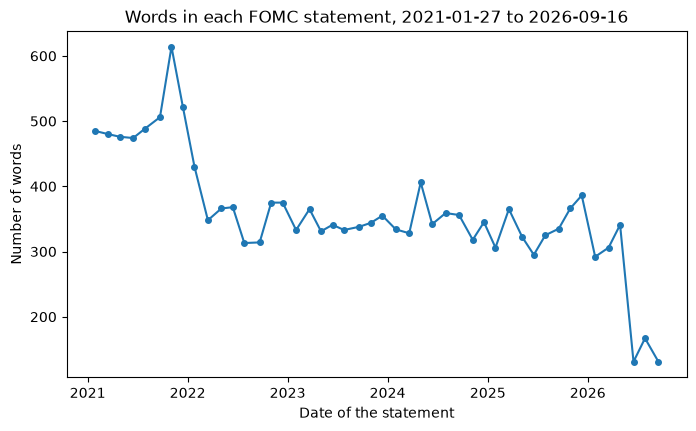

In [55]:
# real dates for the x axis, and the year of each statement for grouping later
statements['meeting'] = pd.to_datetime(statements['date'], format='%Y-%m-%d')
statements['year'] = statements['meeting'].dt.year

print(statements.groupby('year')['words'].agg(['count', 'mean', 'min', 'max']).round(1))

fig, ax = plt.subplots(figsize=(8, 4.5))

# one point for each statement, joined by a line
ax.plot(statements['meeting'], statements['words'], marker='o', markersize=4)

ax.set_title('Words in each FOMC statement, 2021-01-27 to 2026-09-16')
ax.set_xlabel('Date of the statement')
ax.set_ylabel('Number of words')

plt.show()

* By year, the mean word count is 505.5 in 2021, 361.1 in 2022, 342.5 in 2023, 348.5 in 2024, 337.5 in 2025, and 228.0 in the six statements of 2026.
* On the chart the count is between 474 and 614 in 2021, between 295 and 430 from 2022 to 2025, and falls from 341 on 2026-04-29 to 131 on 2026-06-17.
* The chart shows how long each statement is. It does not show why, and a word count cannot.

Q. How many statements contain the word `balance`, and how many times does `inflation` appear in each?

In [56]:
# .str.contains() is True for each text where the pattern is found
has_balance = lower_text.str.contains(r'\bbalance\b')
print('Statements that contain the word balance:', has_balance.sum(), 'of', len(statements))

# without the word edges, the letters are also found inside longer words
print('Statements that contain the letters balance:', lower_text.str.contains('balance').sum())

# .str.count() counts the matches of a pattern in each text
statements['inflation'] = lower_text.str.count(r'\binflation\b')
print(statements[['date', 'inflation']].head(3))
print('Highest count:', statements['inflation'].max(), ' lowest:', statements['inflation'].min(),
      ' total:', statements['inflation'].sum())

Statements that contain the word balance: 25 of 46
Statements that contain the letters balance: 29
         date  inflation
0  2021-01-27         10
1  2021-03-17         10
2  2021-04-28          9
Highest count: 10  lowest: 1  total: 324


* 25 of the 46 statements contain the word `balance`. 29 contain the letters, because `imbalances` and `balances` hold them too.
* The word `inflation` appears 10 times in the statement dated 2021-01-27, between 1 and 10 times in each statement, and 324 times in all.
* `.str.contains()` and `.str.count()` take a regex, so `\b` works here as it did in `re.findall()`. Both were run on the lower-case text, so `Inflation` at the start of a sentence is counted.

**Excel side by side.** With the 46 texts in C2:C47:

| Job | pandas | Excel | Result |
| --- | --- | --- | --- |
| Characters in each text | `.str.len()` | `=LEN(C2)`, filled down | 2,300 for 2023-11-01 |
| Texts that contain a piece of text | `.str.contains('balance').sum()` | `=SUMPRODUCT(--ISNUMBER(SEARCH("balance", C2:C47)))` | 29 |
| Times a piece of text appears in one cell | `.str.count('inflation')` | `=(LEN(C2) - LEN(SUBSTITUTE(LOWER(C2), "inflation", ""))) / LEN("inflation")` | 10 for 2021-01-27 |

The Excel formulas look for a piece of text, not a whole word, so the second row returns 29 and not 25. For `inflation` in this file the two ways of counting agree, because the word never appears inside a longer one.

### Figures from every statement

Q. Pull the range out of every statement with the pattern from section 17.3.

In [57]:
# .str.findall() runs re.findall() on each text and returns a list for each row
found = statements['text'].str.findall(range_pattern)

print(found.head(3))

# how many statements gave 0, 1, or 2 matches
print(found.str.len().value_counts().sort_index())

0    [0 to 1/4 percent]
1    [0 to 1/4 percent]
2    [0 to 1/4 percent]
Name: text, dtype: object
text
0     5
1    39
2     2
Name: count, dtype: int64


* 39 statements gave one match and 2 gave two. 5 statements gave none.
* A pattern that worked on one statement has now been tried on 46, and it came back empty on 5. Before deciding the figure is missing from those five, look at one.

Q. Which statements gave no match, and what does the text look like there?

In [58]:
no_match = statements[found.str.len() == 0]
print(no_match['date'].tolist())

# find the words 'to ... percent' in the first of them, with 12 characters before
text = no_match['text'].iloc[0]
piece = re.search(r'.{12} to \S+ percent', text).group(0)
print('Statement dated', no_match['date'].iloc[0] + ':', piece)

# ascii() shows any character outside the basic English set as a code
print(ascii(piece))

['2025-09-17', '2025-12-10', '2026-01-28', '2026-03-18', '2026-04-29']
Statement dated 2025-09-17: e point to 4 to 4‑1/4 percent
'e point to 4 to 4\u20111/4 percent'


* The five are dated 2025-09-17, 2025-12-10, 2026-01-28, 2026-03-18, and 2026-04-29.
* Printed, the text shows a range that looks exactly like the others. `ascii()` shows the difference: where a hyphen should be, there is `\u2011`.
* `\u2011` is the code of a character called the **non-breaking hyphen**. On screen it is drawn like a hyphen. To Python it is a different character, and the class `[\d/-]` does not include it, so the pattern stopped there.
* Nothing is wrong with the statements. The character exists so that a line of text is not broken at the hyphen. It is the text version of the trailing space in a ticker in notebook 13: invisible to a reader, and real to a program.
* `.` in the pattern is any one character, `{12}` is exactly twelve of them, and `\S` is the opposite of `\s`: any one character that is not white space.

Q. How common is this character in the file?

In [59]:
# '\u2011' is how the character is typed in Python code
print('Statements that contain it:', statements['text'].str.contains('\u2011').sum())
print('Times it appears in all:', statements['text'].str.count('\u2011').sum())

# every piece of text that contains it, counted
pieces = Counter()
for text in statements['text']:
    pieces.update(re.findall(r'\S*\u2011\S*', text))
print(pieces.most_common(4))

Statements that contain it: 26
Times it appears in all: 38
[('mortgage‑backed', 22), ('longer‑term', 7), ('3‑3/4', 4), ('3‑1/2', 3)]


* 26 of the 46 statements contain it, 38 times in all. It is in figures, and it is also in the words `mortgage-backed` and `longer-term` in some statements.
* This is why `clean()` replaces every character that is not a letter with a space. The non-breaking hyphen is not a letter, so it is replaced like any other punctuation, and the two spellings of a word clean to the same tokens.

Q. Widen the pattern to accept either hyphen.

In [60]:
# the class now holds a digit, a slash, the non-breaking hyphen, or a plain hyphen
range_pattern = r'[\d/\u2011-]+ to [\d/\u2011-]+ percent'

found = statements['text'].str.findall(range_pattern)
print(found.str.len().value_counts().sort_index())

# the first match of each statement as its own column
statements['range_text'] = found.str[0]
print(statements[['date', 'range_text']].tail(8))

text
1    44
2     2
Name: count, dtype: int64
          date              range_text
38  2025-10-29      3-3/4 to 4 percent
39  2025-12-10  3-1/2 to 3‑3/4 percent
40  2026-01-28  3‑1/2 to 3‑3/4 percent
41  2026-03-18  3‑1/2 to 3‑3/4 percent
42  2026-04-29  3‑1/2 to 3‑3/4 percent
43  2026-06-17  3-1/2 to 3-3/4 percent
44  2026-07-29  3-1/2 to 3-3/4 percent
45  2026-09-16      3-3/4 to 4 percent


* Now 44 statements give one match and 2 give two. **Every one of the 46 statements has at least one range.**
* `found.str[0]` takes the first item of each list. The new column `range_text` holds the figure as text, in the statement's own style.
* The lesson is the same as with the names: a pattern is tested by a count. 46 statements, 46 expected, 41 found was the signal.

In Excel, `=UNICODE(MID(C2, n, 1))` returns the code of the character at position `n`. A plain hyphen returns 45 and the non-breaking hyphen returns 8209. `=SUBSTITUTE(C2, UNICHAR(8209), "-")` replaces one with the other. Both need the text to reach Excel intact. The file is saved as UTF-8, and a CSV opened by double-click is read in the Windows code page, where this one character arrives as three others and the code at that position is 226. Bring the file in with Data, Get Data, From Text/CSV, with File Origin set to 65001: Unicode (UTF-8).

### A function on every row

Q. Clean every statement with `clean()` and remove the stopwords.

In [61]:
# apply() calls a function once for each value in the column and collects the results
statements['tokens'] = statements['text'].apply(clean)


def remove_stop_words(tokens):
    # keep the tokens that are not on nltk's list
    return [token for token in tokens if token not in stop_words]


statements['kept'] = statements['tokens'].apply(remove_stop_words)

statements['n_tokens'] = statements['tokens'].str.len()
statements['n_kept'] = statements['kept'].str.len()

print(statements[['date', 'words', 'n_tokens', 'n_kept']].head(3))
print('Tokens in all 46 statements:', statements['n_tokens'].sum())
print('After stopword removal:', statements['n_kept'].sum())

# the check against section 17.5
print('Statement dated 2023-11-01:',
      statements.loc[statements['date'] == '2023-11-01', ['n_tokens', 'n_kept']].values.tolist())

         date  words  n_tokens  n_kept
0  2021-01-27    485       484     304
1  2021-03-17    480       478     301
2  2021-04-28    476       475     301
Tokens in all 46 statements: 16446
After stopword removal: 10204
Statement dated 2023-11-01: [[343, 217]]


* `.apply()` is new. It takes a function, **without brackets**, and runs it on each value of the column. `statements['text'].apply(clean)` is `clean(text)` for all 46 texts.
* The 46 statements hold 16,446 tokens, and 10,204 after stopword removal.
* The row for 2023-11-01 shows 343 and 217, the numbers worked out by hand in sections 17.4 and 17.5. The function does to every row what was done to one.
* In Excel, `.apply()` is a formula filled down a column: the same calculation on every row.

Q. Which tokens are the most common across all 46 statements?

In [62]:
# one Counter, fed the kept tokens of each statement in turn
all_counts = Counter()
for tokens in statements['kept']:
    all_counts.update(tokens)

print('Different tokens:', len(all_counts))
print(all_counts.most_common(8))

Different tokens: 507
[('committee', 477), ('inflation', 324), ('policy', 196), ('percent', 190), ('monetary', 170), ('economic', 163), ('rate', 163), ('range', 159)]


* 507 different tokens across the 46 statements. The most common is `committee`, 477 times, then `inflation` 324, `policy` 196, `percent` 190, `monetary` 170, `economic` 163, `rate` 163, and `range` 159.

### A document-term table

A **document-term table** has one row for each document and one column for each word of interest, and each cell is a count. It is the standard way to hand text to anything that works on numbers.

Q. Build the table for eight words.

In [63]:
# eight plain words that appear in the statements
terms = ['committee', 'inflation', 'percent', 'economic', 'rate', 'risks', 'employment', 'labor']

# one Counter for each statement
counters = statements['kept'].apply(Counter)

# one column for each term: its count in every statement
term_table = pd.DataFrame({term: [counter[term] for counter in counters] for term in terms})
term_table.index = statements['date']

print(term_table.shape)
print(term_table.head())
print(term_table.sum())

(46, 8)
            committee  inflation  percent  economic  rate  risks  employment  \
date                                                                           
2021-01-27         10         10        7         5     2      2           6   
2021-03-17         10         10        8         5     2      2           6   
2021-04-28         10          9        7         4     2      2           5   
2021-06-16         10          9        7         3     2      2           5   
2021-07-28         11          9        7         3     2      2           5   

            labor  
date               
2021-01-27      2  
2021-03-17      2  
2021-04-28      2  
2021-06-16      2  
2021-07-28      2  
committee     477
inflation     324
percent       190
economic      163
rate          163
risks         121
employment    106
labor          62
dtype: int64


* 46 rows and 8 columns. The first row says that in the statement dated 2021-01-27 the word `committee` appears 10 times, `inflation` 10, `percent` 7, `economic` 5, `rate` 2, `risks` 2, `employment` 6, and `labor` 2.
* The column totals are 477 for `committee`, 324 for `inflation`, 190 for `percent`, 163 for `economic`, 163 for `rate`, 121 for `risks`, 106 for `employment`, and 62 for `labor`.
* **Across the 46 statements the whole word rate appears 163 times.** That is the second number to keep for the AI check.
* The eight words were chosen because they are common, ordinary words in the file. The table reports how often each appears. It attaches no meaning to a count going up or down.

Q. Draw the table as a heatmap.

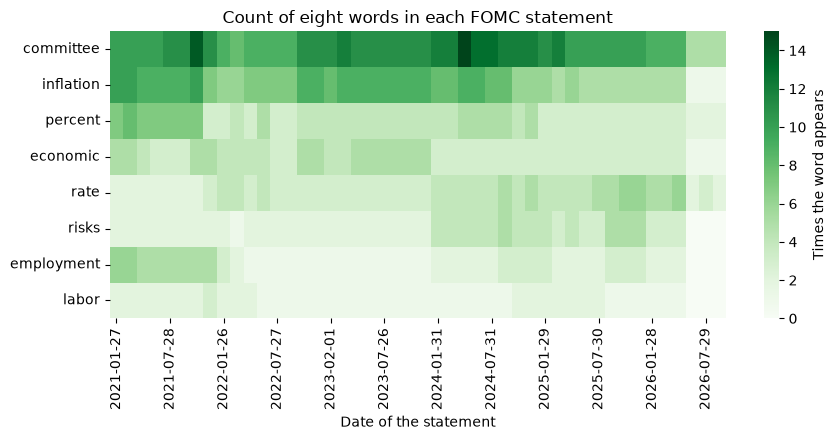

In [64]:
fig, ax = plt.subplots(figsize=(9, 4.5))

# .T turns the table on its side: one row for each word, one column for each statement
# xticklabels=4 labels every fourth statement, so the dates do not overlap
sns.heatmap(term_table.T, cmap='Greens', xticklabels=4, cbar_kws={'label': 'Times the word appears'}, ax=ax)

ax.set_title('Count of eight words in each FOMC statement')
ax.set_xlabel('Date of the statement')
ax.set_ylabel('')
fig.tight_layout()

plt.show()

* Each column is a statement and each row is a word. The darker the cell, the more often the word appears in that statement.
* The `committee` row is the darkest, with counts from 5 to 15. The `labor` row is the lightest, from 0 to 3.
* The last three columns, the statements from 2026-06-17 on, are light in every row. Those are also the three shortest statements, with 131, 167, and 131 words. A count depends on how long the document is, which is the next question.

In Excel, the same picture is the table of counts with Home, Conditional Formatting, Color Scales applied to it.

Q. Per 100 tokens, how often does each word appear, by year?

In [65]:
# divide each row of counts by the number of kept tokens in that statement, times 100
# .values gives the plain numbers, so that pandas divides row by row without matching labels
per_100 = term_table.div(statements['n_kept'].values, axis=0) * 100

# the mean of each column within each year
print(per_100.groupby(statements['year'].values).mean().round(2))

      committee  inflation  percent  economic  rate  risks  employment  labor
2021       3.47       2.93     2.13      1.32  0.68   0.64        1.69   0.68
2022       4.17       3.23     1.61      1.76  1.50   0.83        0.60   0.61
2023       5.18       4.13     1.86      2.21  1.40   0.93        0.47   0.47
2024       5.94       3.64     2.17      1.42  2.01   1.95        1.13   0.60
2025       5.05       2.57     1.46      1.46  2.30   1.94        1.22   0.80
2026       5.31       1.91     1.97      1.38  2.74   0.80        0.53   0.27


* Per 100 tokens kept, `inflation` is 2.93 in 2021, 4.13 in 2023, and 1.91 in 2026, and `committee` is 3.47 in 2021 and 5.94 in 2024.
* Dividing by the length puts a long statement and a short one on the same footing. It is the text version of a market value weight: a count as a share of the total.

Q. What share of each year's statements contain a word at all?

In [66]:
# True where a statement contains the word at least once
check_words = ['employment', 'labor', 'balance', 'uncertain']
contains = pd.DataFrame({word: [word in tokens for tokens in statements['kept']] for word in check_words})

# the mean of a True and False column is the share that is True
share = contains.groupby(statements['year'].values).mean() * 100
print(share.round(1))

      employment  labor  balance  uncertain
2021       100.0  100.0      0.0        0.0
2022       100.0  100.0     75.0       25.0
2023       100.0  100.0      0.0       87.5
2024       100.0  100.0    100.0      100.0
2025       100.0  100.0    100.0       12.5
2026        50.0   50.0     50.0       16.7


* `employment` and `labor` are in 100 percent of the statements of every year from 2021 to 2025, and in 50 percent of the six statements of 2026.
* `balance` is in none of the 2021 statements, 75 percent in 2022, none in 2023, 100 percent in 2024 and 2025, and 50 percent in 2026.
* `uncertain` is in none of the 2021 statements, 25 percent in 2022, 87.5 percent in 2023, 100 percent in 2024, 12.5 percent in 2025, and 16.7 percent in 2026.
* `word in tokens` tests a list of whole tokens, so `uncertain` does not match `uncertainty`. These are shares of documents that contain a word. They are not a measure of anything else.

In Excel, with the year in column D and a TRUE or FALSE column for the word in column E, the share for one year is `=COUNTIFS(D2:D47, 2023, E2:E47, TRUE) / COUNTIF(D2:D47, 2023)`, which returns 0.875 for `uncertain` in 2023.

### How much wording changed

Two statements can be compared by the words they share. Take the set of different tokens in each. The **Jaccard similarity** is the number of tokens in both sets divided by the number of tokens in either:

`similarity = tokens in both / tokens in either`

It is 1 when the two use exactly the same set of words and 0 when they share none.

Q. Try it on two short lists.

In [67]:
def similarity(first, second):
    # each list becomes a set: every different token once
    first_set = set(first)
    second_set = set(second)
    # & gives the tokens in both sets, and | gives the tokens in either
    return len(first_set & second_set) / len(first_set | second_set)


a = ['inflation', 'remains', 'elevated']
b = ['inflation', 'remains', 'somewhat', 'elevated', 'inflation']

# sorted() prints a set in alphabetical order
print('In both:', sorted(set(a) & set(b)))
print('In either:', sorted(set(a) | set(b)))
print('Similarity:', similarity(a, b))

In both: ['elevated', 'inflation', 'remains']
In either: ['elevated', 'inflation', 'remains', 'somewhat']
Similarity: 0.75


* 3 tokens are in both and 4 are in either, so the similarity is 0.75.
* `inflation` is in the second list twice and counts once. A set ignores repeats and order. The measure sees which words are used, not how often or where.

Q. Compare each statement with the one before it.

In [68]:
# the first statement has nothing before it
values = [None]

# for every other statement, the similarity with the statement one row above
for i in range(1, len(statements)):
    values.append(similarity(statements['kept'].iloc[i], statements['kept'].iloc[i - 1]))

statements['similarity'] = values

print('Mean:', round(statements['similarity'].mean(), 3))

lowest = statements.loc[statements['similarity'].idxmin()]
highest = statements.loc[statements['similarity'].idxmax()]
print('Lowest:', lowest['date'], round(lowest['similarity'], 3))
print('Highest:', highest['date'], round(highest['similarity'], 3))
print('Below 0.7:', statements.loc[statements['similarity'] < 0.7, 'date'].tolist())

Mean: 0.832
Lowest: 2026-06-17 0.196
Highest: 2022-12-14 0.982
Below 0.7: ['2022-03-16', '2024-01-31', '2026-01-28', '2026-06-17', '2026-09-16']


* On average, a statement shares 0.832 of its set of words with the one before it.
* The highest value is 0.982, for the statement dated 2022-12-14 against the one before it. The lowest is 0.196, for the statement dated 2026-06-17.
* Five statements are below 0.7: those dated 2022-03-16, 2024-01-31, 2026-01-28, 2026-06-17, and 2026-09-16.

Q. Draw it.

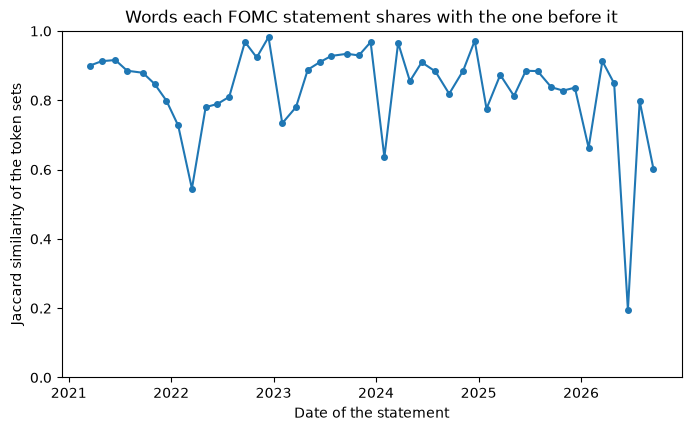

In [69]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(statements['meeting'], statements['similarity'], marker='o', markersize=4)

# the y axis runs over the whole possible range of the measure
ax.set_ylim(0, 1)
ax.set_title('Words each FOMC statement shares with the one before it')
ax.set_xlabel('Date of the statement')
ax.set_ylabel('Jaccard similarity of the token sets')

plt.show()

* Most points lie between 0.7 and 1. The five points below 0.7 are 0.545 on 2022-03-16, 0.636 on 2024-01-31, 0.663 on 2026-01-28, 0.196 on 2026-06-17, and 0.602 on 2026-09-16.
* The chart measures **how much wording changed** from one statement to the next: a low point means many words were added or dropped. It does not say which words they were or what a change means. The measure treats every word alike.
* The first statement has no value, because there is nothing before it. `mean()` and the chart leave it out.

Q. Put the numbers together in the table the portfolio manager asked for.

In [70]:
# one row for each statement: its length, its figure, two word counts, and the similarity
summary = statements[['date', 'words', 'n_kept', 'range_text', 'inflation', 'similarity']].copy()
summary['similarity'] = summary['similarity'].round(3)

print(summary.shape)
summary.tail(6)

(46, 6)


,date,words,n_kept,range_text,inflation,similarity
40,2026-01-28,292,178,3‑1/2 to 3‑3/4 percent,5,0.663
41,2026-03-18,306,186,3‑1/2 to 3‑3/4 percent,5,0.913
42,2026-04-29,341,202,3‑1/2 to 3‑3/4 percent,5,0.849
43,2026-06-17,131,80,3-1/2 to 3-3/4 percent,1,0.196
44,2026-07-29,167,101,3-1/2 to 3-3/4 percent,1,0.798
45,2026-09-16,131,79,3-3/4 to 4 percent,1,0.602


* 46 rows and 6 columns. Every cell is a count, a figure copied from the text, or a ratio of counts, and every one can be checked against the published statement.
* That is where this notebook stops. The table describes the wording of 46 documents. What the documents mean is not in it.

## 17.8 AI Check

You ask an AI assistant: how many times does the word rate appear in the statements? It gives you the code below. It was written for this course in the style of an AI assistant's answer. It runs without an error.

Q. Read the code before you run it. The lesson has two numbers for this: the word rate appears 3 times in the statement dated 2023-11-01, and 163 times across the 46 statements. What will this code print?

In [71]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
# count the word 'rate' in one statement and in all statements
one = statements.loc[statements['date'] == '2023-11-01', 'text'].iloc[0]
print('In the statement dated 2023-11-01:', one.count('rate'))

total = statements['text'].str.count('rate').sum()
print('In all 46 statements:', total)

In the statement dated 2023-11-01: 4
In all 46 statements: 188


* It prints 4 and 188. The lesson's numbers are 3 and 163.
* No error, no warning, and both answers look reasonable. The only way to catch it is to hold a number worked out another way.
* The bug is `count('rate')`. It counts the four letters wherever they fall, inside longer words too.

Q. Which words did it count?

In [72]:
# every word that contains the letters rate, across all statements
containing = Counter()
for text in statements['text']:
    containing.update(re.findall(r'\w*rate\w*', text))
print(containing)

# the fix: ask for the whole word
print('Whole word, one statement:', len(re.findall(r'\brate\b', one)))
print('Whole word, all statements:', statements['text'].str.count(r'\brate\b').sum())

Counter({'rate': 163, 'moderately': 14, 'moderated': 7, 'moderate': 3, 'concentrated': 1})
Whole word, one statement: 3
Whole word, all statements: 163


* The 188 is made of 163 for `rate` and 25 for other words that contain it: `moderately` 14 times, `moderated` 7, `moderate` 3, and `concentrated` 1.
* With `\b` on each side the code returns 3 and 163, the lesson's numbers.
* The code was not careless in an obvious way. `count()` is the natural tool, and on many words it gives the right answer. The check is always the same: one number worked out by hand, on one document small enough to read.

## You Can Now

* Measure, search, slice, split, join, strip, and replace text with string methods.
* Write a regular expression from pieces: `\d`, `\w`, `\s`, `\b`, character classes, `+`, `*`, `?`, `{n}`, anchors, and groups.
* Use `re.findall()`, `re.search()`, and `re.sub()`, and handle a search that finds nothing.
* Test a pattern against a count from somewhere else, and fix one that matches too much or too little.
* Tell a greedy pattern from a lazy one, and test a whole value with `re.fullmatch()` and `.str.fullmatch()`.
* Take a bond description apart into ticker, coupon, and maturity, and test the shape of a CUSIP.
* Spot a character that looks like another with `ascii()`.
* Clean text in steps: lower case, remove what is not a letter, reduce white space, split into tokens.
* Remove stopwords with a list of your own and with nltk's list, and stem tokens with the Porter stemmer, knowing its limits.
* Count tokens with `Counter`.
* Work on a whole column with `.str.lower()`, `.str.len()`, `.str.contains()`, `.str.count()`, `.str.findall()`, and `.apply()`.
* Build a document-term table, draw it as a heatmap, and compare documents by the words they share.
* Match each step to Excel: `LEN`, `LOWER`, `UPPER`, `TRIM`, `FIND`, `SEARCH`, `LEFT`, `MID`, `RIGHT`, `SUBSTITUTE`, `TEXTSPLIT`, `TEXTJOIN`, `COUNTIF` with wildcards, `REGEXTEST`, `REGEXEXTRACT`, `REGEXREPLACE`, Find and Replace, and Flash Fill.

The next notebook is a case study. It applies these tools to the same statements, and turns their wording into a score.

## Exercises

Exercises 1 to 3 use a second statement, the one dated 2022-09-21, stored as `other`. Exercise 4 and the AI check, exercise 9, use the whole table. Exercises 5 to 8 use bond descriptions and identifiers typed from the course's synthetic holdings file, and exercise 8 asks you to write a function. Every answer is a count, a figure, or a piece of text taken from a file. None is a reading of what a statement means.

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports the libraries, defines `check`, a small function that marks your answers, defines `clean()` as in the lesson, loads nltk's stopword list as `stop_words`, and loads a fresh `statements`. It prints the shape of the table, (46, 3), the number of stopwords, 198, and the type of `other`.

In [73]:
import os
import re
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, list):
        # a list of values: the same values in the same order
        correct = list(answer) == expected
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


def clean(text):
    # the four cleaning steps of the lesson: lower case, letters only, single spaces, tokens
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.split(' ')


# nltk's English stopword list, downloaded once
ready = nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = stopwords.words('english')

# a fresh copy of the statements. In Colab the file is read from GitHub.
if os.path.exists('../../../data/fomc_statements.csv'):
    data_file = '../../../data/fomc_statements.csv'
else:
    data_file = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/fomc_statements.csv'

statements = pd.read_csv(data_file)

# the statement the first three exercises use
other = statements.loc[statements['date'] == '2022-09-21', 'text'].iloc[0]

print(statements.shape)
print(len(stop_words))
print(type(other))

(46, 3)


198
<class 'str'>


### Exercise 1

Q. For the statement dated 2022-09-21, `other`: how many characters does it have, how many words by `split()`, and how many times does `inflation` appear when capitals are ignored? Store the answers in **ex1_characters**, **ex1_words**, and **ex1_inflation**.

In [74]:
ex1_characters = ...
ex1_words = ...
ex1_inflation = ...

In [75]:
check('Exercise 1 characters', ex1_characters, 2066)
check('Exercise 1 words', ex1_words, 314)
check('Exercise 1 inflation', ex1_inflation, 7)

Exercise 1 characters: not attempted yet
Exercise 1 words: not attempted yet
Exercise 1 inflation: not attempted yet


### Exercise 2

Q. With regular expressions, on `other`: find the range written as `... to ... percent` and store the list that `re.findall()` returns in **ex2_range**. Use groups to take the two ends, and turn the upper end into a number: `3-1/4` is 3 plus 1 divided by 4. Store it in **ex2_upper**. Then count the names in the last paragraph and store the count in **ex2_names**.

In [76]:
ex2_range = ...
ex2_upper = ...
ex2_names = ...

In [77]:
check('Exercise 2 range', ex2_range, ['3 to 3-1/4 percent'])
check('Exercise 2 upper end', ex2_upper, 3.25)
check('Exercise 2 names', ex2_names, 12)

Exercise 2 range: not attempted yet
Exercise 2 upper end: not attempted yet
Exercise 2 names: not attempted yet


### Exercise 3

Q. Clean `other` with `clean()`. How many tokens are there? Remove nltk's stopwords. How many are left, and which token is the most common? Store the answers in **ex3_tokens**, **ex3_kept**, and **ex3_top**.

In [78]:
ex3_tokens = ...
ex3_kept = ...
ex3_top = ...

In [79]:
check('Exercise 3 tokens', ex3_tokens, 315)
check('Exercise 3 kept', ex3_kept, 201)
check('Exercise 3 most common', ex3_top, 'committee')

Exercise 3 tokens: not attempted yet
Exercise 3 kept: not attempted yet
Exercise 3 most common: not attempted yet


### Exercise 4

Q. On the whole table: add a `words` column with the word count of each statement by `split()`, and a `year` column. Which year has the highest mean word count, and what is that mean? Store them in **ex4_year** and **ex4_mean**, the mean rounded to 1 decimal place. Then count the statements that contain the whole word `uncertain`, capitals ignored, and store the count in **ex4_uncertain**. Draw the mean word count by year as a bar chart.

In [80]:
ex4_year = ...
ex4_mean = ...
ex4_uncertain = ...

In [81]:
check('Exercise 4 year', ex4_year, 2021)
check('Exercise 4 mean words', ex4_mean, 505.5)
check('Exercise 4 uncertain', ex4_uncertain, 19)

Exercise 4 year: not attempted yet
Exercise 4 mean words: not attempted yet
Exercise 4 uncertain: not attempted yet


### Exercise 5

Exercises 5 to 8 use two short lists typed from rows of the course's synthetic holdings file. Run the next cell to create them: six bond descriptions in `more_descriptions`, and nine identifiers in `identifiers`, some of them damaged on purpose.

In [82]:
# six descriptions, typed by hand: ticker, coupon in percent, maturity as month/day/year
more_descriptions = [
    'KRIX 6.625 05/09/2033',
    'BEZL 6.125 04/09/2053',
    'ZEPN 5 08/16/2036',
    'GALX  9.25 06/17/2038',
    'TROE 4.375 12/26/2027',
    'LORE 8.625 06/09/2032',
]

# nine identifiers, typed by hand
identifiers = ['99087JAG1', '99039NAG1', '99138IAF4', '99088kah5', '99093PAA', '99114KAB6 ', '99053-BAG8', '99057FAC4', '99005FAA1']

print(f'Descriptions: {len(more_descriptions):,}   identifiers: {len(identifiers):,}')

Descriptions: 6   identifiers: 9


Q. Pull the coupon out of each of the six descriptions with a group, and turn it into a number. Store the list of six numbers, in the order of the descriptions, in **ex5_coupons**, and the highest coupon in **ex5_highest**. Look at the descriptions first: one coupon has no decimal point, and one line has two spaces.

In [83]:
ex5_coupons = ...
ex5_highest = ...

In [84]:
check('Exercise 5 coupons', ex5_coupons, [6.625, 6.125, 5.0, 9.25, 4.375, 8.625])
check('Exercise 5 highest coupon', ex5_highest, 9.25)

Exercise 5 coupons: not attempted yet
Exercise 5 highest coupon: not attempted yet


### Exercise 6

Q. Pull the maturity out of each of the six descriptions as text, and turn the six into dates with `pd.to_datetime()` and `format='%m/%d/%Y'`. Store the year of the latest maturity in **ex6_latest_year** and the number of bonds that mature after 2030-12-31 in **ex6_after_2030**.

In [85]:
ex6_latest_year = ...
ex6_after_2030 = ...

In [86]:
check('Exercise 6 latest year', ex6_latest_year, 2053)
check('Exercise 6 maturing after 2030', ex6_after_2030, 5)

Exercise 6 latest year: not attempted yet
Exercise 6 maturing after 2030: not attempted yet


### Exercise 7

Q. Test each of the nine values in `identifiers` against the shape of a CUSIP: nine characters, each a digit or a capital letter. Store the number that have the shape in **ex7_valid**, and the list of those that do not, in the order of the list, in **ex7_failed**. Print the failures with `repr()`.

In [87]:
ex7_valid = ...
ex7_failed = ...

In [88]:
check('Exercise 7 with the shape', ex7_valid, 5)
check('Exercise 7 failures', ex7_failed, ['99088kah5', '99093PAA', '99114KAB6 ', '99053-BAG8'])

Exercise 7 with the shape: not attempted yet
Exercise 7 failures: not attempted yet


### Exercise 8

Q. Write a function `parse_description(text)` that **returns** a dictionary with three keys: `'ticker'` as text, `'coupon'` as a number, and `'maturity'` as the text of the date, as typed. It must read a coupon with no decimal point and a line with two spaces. The check cell calls your function on three descriptions.

In [89]:
def parse_description(text):
    """Return a dictionary with the ticker, the coupon as a number, and the maturity text of one bond description."""
    return ...

In [90]:
check('Exercise 8 plain description', parse_description('KRIX 6.625 05/09/2033'), {'ticker': 'KRIX', 'coupon': 6.625, 'maturity': '05/09/2033'})
check('Exercise 8 whole-number coupon', parse_description('ZEPN 5 08/16/2036'), {'ticker': 'ZEPN', 'coupon': 5.0, 'maturity': '08/16/2036'})
check('Exercise 8 two spaces', parse_description('GALX  9.25 06/17/2038'), {'ticker': 'GALX', 'coupon': 9.25, 'maturity': '06/17/2038'})

Exercise 8 plain description: not attempted yet
Exercise 8 whole-number coupon: not attempted yet
Exercise 8 two spaces: not attempted yet


### Exercise 9: AI check

You ask an AI assistant to pull the range out of every statement and say how many statements have one. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug.

Q. Read the code before you run it. How many statements should have a range? The lesson worked it out. Then run the code. Does the answer agree with you?

In [91]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
# a number, the word to, a number, and percent
pattern = r'\d+ to \d+ percent'

found = statements['text'].str.findall(pattern)

# the number of statements with at least one match
ex9_statements = int((found.str.len() > 0).sum())

# the matches themselves
print(found[found.str.len() > 0].tolist())
print('Statements with a range:', ex9_statements)

[['4 to 1 percent'], ['4 to 4 percent'], ['4 to 5 percent'], ['4 to 5 percent'], ['4 to 4 percent'], ['4 to 4 percent']]
Statements with a range: 6


Q. Find the bug and fix the code in the cell above, so that **ex9_statements** holds the right count. Then store the range found in the first statement, as text, in **ex9_first**.

In [92]:
ex9_first = ...

In [93]:
check('Exercise 9 statements with a range', ex9_statements, 46)
check('Exercise 9 first range', ex9_first, '0 to 1/4 percent')

Exercise 9 statements with a range: not yet. You have 6
Exercise 9 first range: not attempted yet
